## Matrices Operations and Linear Regression

Suggestion: explore the NumPy library documentation to find the right functions to solve the exercises below

NumPy docs: https://numpy.org/doc/stable/

## Setup

In [35]:
import numpy as np  # This should be all the dependencies you will need


### 1.1 Matrix Element Wise-multiplication

Consider the two following matrices 

$$
A = \begin{pmatrix}
1&0&0\\
0&1&0\\
0&0&1\\
\end{pmatrix}
$$

and

$$
B = \begin{pmatrix}
1&2&3\\
4&5&6\\
7&8&9\\
\end{pmatrix}
$$

Write a Python program that computes the element-wise multiplication of the two matrices, i.e.

$$
C = \begin{pmatrix}
1&0&0\\
0&5&0\\
0&0&9\\
\end{pmatrix}
$$

In [36]:
## write your code here

a = np.array([1, 0, 0, 0, 1, 0, 0, 0, 1]).reshape(3, 3)
a

array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]])

In [37]:
a = np.eye(3)
a

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [38]:
b = np.arange(1,10,1)
b = b.reshape(3,3)
b

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [39]:
b = np.arange(1,10,1).reshape(3,3)
b

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [40]:
c = np.multiply(a,b)
c

array([[1., 0., 0.],
       [0., 5., 0.],
       [0., 0., 9.]])

In [41]:
c = a * b
c

array([[1., 0., 0.],
       [0., 5., 0.],
       [0., 0., 9.]])

### Hmmm... syntactically correct and multiplies two matrices, but does this abide by the laws of matrices?

### Be aware that multiplying by an identity matrix is essentially multiplying by 1


In [42]:
b * 1

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

# So safer to use dot product, or matmul

In [43]:
c = np.dot(a,b)
c

array([[1., 2., 3.],
       [4., 5., 6.],
       [7., 8., 9.]])

In [44]:
c = np.matmul(a,b)
c

array([[1., 2., 3.],
       [4., 5., 6.],
       [7., 8., 9.]])

In [45]:
c = a @ b 
c

array([[1., 2., 3.],
       [4., 5., 6.],
       [7., 8., 9.]])

## Key difference: 

### `matrix multiplication` rows of the first matrix are multiplied by columns of the second matrix and <b>summed up</b>. Combines the values in a structured way.

### `element-wise multiplication` is performed between matrices of the <b>same shape</b>. Multiply corresponding elements.

### 1.2 Matrix-Matrix Multiplication

Consider the following two matrices

$$
A = \begin{pmatrix}
2&1&3\\
1&1&2\\
\end{pmatrix}
$$

and

$$
B = \begin{pmatrix}
1&2\\
5&6\\
7&9\\
\end{pmatrix}
$$

Write a Python program that computes the matrix multiplication of the two matrices, i.e.

$$
C = A \times B = \begin{pmatrix}
28&37\\
20&26\\
\end{pmatrix}
$$
Run the same program for the matrices of Exercise 1.1. Which result do you get?

In [14]:
## write your code here
a = np.array([[2,1,3], [1,1,2]])
a

array([[2, 1, 3],
       [1, 1, 2]])

In [13]:
b = np.array([[1,2], [5,6], [7,9]])
b

array([[1, 2],
       [5, 6],
       [7, 9]])

### Problem! A and B are different shapes... so cannot perform element wise multiplication...

In [15]:
c = np.multiply(a, b)
c

ValueError: operands could not be broadcast together with shapes (2,3) (3,2) 

### Instead... seek the 'dot product' which aggregates the elements

![matrix_multiplication](https://www.mathsisfun.com/algebra/images/matrix-multiply-a.svg)

In our case - the first set of rows and columns would be:  
2 x 1 = 2  
1 x 5 = 5  
3 x 7 = 21

21 + 2 + 5 = 28 

In [16]:
c = np.dot(a,b)
c

array([[28, 37],
       [20, 26]])

In [17]:
## can also use the @ operator for short-hand...

c = a @ b
c

array([[28, 37],
       [20, 26]])

In [18]:
c = np.matmul(a,b)
c

array([[28, 37],
       [20, 26]])

### 1.3 Linear Regression

We generate some fake "height" and "weight" data about babies between 0 and 12 months of age.

We  want to create  linear predictor that predicts the weight from the baby age (in month).

In [19]:
# generate some fake "height" and "weight" data about babies between 0 and 12 months of age
babies = range(10)
months = np.arange(12)
data = [(month + np.random.rand(), np.dot(month, 24.7) + 96 + np.random.normal(loc=0, scale=20))
        for month in months
        for baby in babies]
month_data = [element[0] for element in data]
weight_data = [element[1] for element in data]
# Let's put the month_data into the matrix X together with the biases column vector
X_1 = np.array(month_data)    # here we put month_data into a row vector called X_1
X_0 = np.ones([X_1.shape[0], 1]) # this is the biases column vector
X_1 = X_1[:, np.newaxis]    # here we convert X_1 from a row vector to a column vector
X = np.concatenate((X_0, X_1), axis=1) # here we concatenate the biases vector to the month_data vector

# Let's put the weight_data into the output vector y
y = np.array(weight_data)

In [20]:
X.ndim, y.ndim

(2, 1)

In [21]:
X.shape, y.shape

((120, 2), (120,))

### X column 0 contains the biases - they're all '1.0'
### X column 1 contains the month data (values between 0-12)

In [22]:
X[6:12]

array([[1.        , 0.02026761],
       [1.        , 0.7899029 ],
       [1.        , 0.78088232],
       [1.        , 0.13207166],
       [1.        , 1.88762971],
       [1.        , 1.83460979]])

In [25]:
X[13,0]

1.0

### y contains the weight data - only one column

In [27]:
y[10:15]

array([142.08506511, 135.31307495, 135.86940201, 116.99921616,
       102.45169695])

Our features matrix $X$ as a column of biases (all set to 1) and our column of input features (i.e age).

Our labels verctor $y$ is a row vector with our output labels (weights in some unspecified unit)

In [28]:
X

array([[ 1.        ,  0.4603449 ],
       [ 1.        ,  0.49991302],
       [ 1.        ,  0.14475267],
       [ 1.        ,  0.35242357],
       [ 1.        ,  0.53661754],
       [ 1.        ,  0.01214322],
       [ 1.        ,  0.02026761],
       [ 1.        ,  0.7899029 ],
       [ 1.        ,  0.78088232],
       [ 1.        ,  0.13207166],
       [ 1.        ,  1.88762971],
       [ 1.        ,  1.83460979],
       [ 1.        ,  1.55940293],
       [ 1.        ,  1.02053412],
       [ 1.        ,  1.92753571],
       [ 1.        ,  1.59872581],
       [ 1.        ,  1.5882269 ],
       [ 1.        ,  1.39643037],
       [ 1.        ,  1.45786175],
       [ 1.        ,  1.92094822],
       [ 1.        ,  2.80618061],
       [ 1.        ,  2.94066144],
       [ 1.        ,  2.34451174],
       [ 1.        ,  2.12915475],
       [ 1.        ,  2.88477848],
       [ 1.        ,  2.87140478],
       [ 1.        ,  2.01233866],
       [ 1.        ,  2.19045019],
       [ 1.        ,

In [29]:
y

array([106.60289568,  85.91790336,  76.37710071,  72.33999266,
        82.95051618,  62.14637038, 102.7940345 ,  93.04532739,
       102.98183798,  91.58338033, 142.08506511, 135.31307495,
       135.86940201, 116.99921616, 102.45169695, 125.89647586,
        95.98960993,  80.56898723, 150.38681271, 139.82876825,
       142.24085288, 192.38299687, 123.6985539 , 152.29552286,
       147.01934176, 171.58080859, 153.68905608, 148.56313588,
       136.88403971, 128.61817432, 188.56875642, 179.35063803,
       158.10502725, 141.87302824, 159.61502457, 153.99549587,
       168.12653211, 149.24566957, 143.79311358, 199.5639605 ,
       206.27620227, 204.26004366, 174.78424576, 233.266663  ,
       182.90909876, 180.62095178, 165.5037148 , 187.02157941,
       209.76644893, 178.32819285, 214.64260064, 225.12900962,
       199.46430429, 203.51561986, 235.92984198, 215.44135603,
       238.85529558, 236.82272875, 236.47475553, 225.10106953,
       227.25138125, 250.10451936, 260.83468804, 248.21

## Problem! X and Y are different shapes.. 
## Transpose - 'flips rows and cols'

In [30]:
#tranpose 'flips on an axis'
# from 
#.    x x
#.    x x
#.    x x 

# to

#     x x x
#.    x x x

In [31]:
a

a = np.array([6, 7, 1, 9, 5, 2]).reshape(3, 2)

a

array([[6, 7],
       [1, 9],
       [5, 2]])

In [32]:
c = np.transpose(a)
c

array([[6, 1, 5],
       [7, 9, 2]])

## Let's apply .T to transpose X (effectively converts two columns to one column of two rows)
### Notice how the 1s of one column are now in one array (one row), and the weight data (from another column) is another array (one row)...

In [57]:
X_T = X.T
X_T

array([[ 1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1. 

In [58]:
X_T.shape

(2, 120)

In [59]:
X_T.ndim

2

In [60]:
y.ndim

1

Given: 
- the two-dimensional array (i.e. a matrix) $X$, containing a column with biases (all set to 1) and a column containing the ages of children (expressed in months)
- a one dimensional column array $y$ containing the weights of the same children expressed in kilograms
Write a function to compute the best fit  using the Linear Regression model with Ordinary Least Squares Method:
$$
\beta = (X^T X)^{-1}X^T y
$$
where, given a matrix $A$, $A^T$ is the transpose matrix of A, and $A^{-1}$ is the inverse matrix of $A$.


The $X$ and $y$ arrays have precomputed for you in the cell above

## $ \beta $ is the vector of regression coefficients in linear regression. 

$ \beta  = \begin{bmatrix}
\beta_0 \\
\beta_1 \\
\end{bmatrix} \quad
$
### $ \beta_0 $ : The <b>intercept (constant)</b> — the value of $ y $ when $ x = 0 $.

### $ \beta_1 $ : The <b>slope (gradient)</b> — the change in $ y $ for a one-unit increase in $ x $.

### $ \epsilon $ : The residual (error).

### $ y = \beta_0 + \beta_1 x + \epsilon $

### $ y = mx + c$


# Split the formula into parts
#### 1. $(X^T X)$

Remember the shapes of X.T and X are different...

In [33]:
X.T * X

ValueError: operands could not be broadcast together with shapes (2,120) (120,2) 

In [62]:
xtx = np.dot(X.T, X)
xtx

array([[ 120.        ,  717.40468132],
       [ 717.40468132, 5716.79345411]])

#### 2. $(X^T X)^{-1}$

In [63]:
inv_xtx = np.linalg.inv(xtx)
inv_xtx

array([[ 0.03336408, -0.00418688],
       [-0.00418688,  0.00070034]])

#### 3. $X^T Y$

In [64]:
xty = np.dot(X.T, y)
xty

array([ 27813.66929338, 202587.01851292])

### Multiply inv_xtx and xty together

Even though they are different shapes they can still be multipled... but is the outcome as intended?

In [65]:
inv_xtx.shape, xty.shape

((2, 2), (2,))

In [66]:
inv_xtx * xty

array([[ 927.97757726, -848.20829162],
       [-116.45259942,  141.87946865]])

### Dot product gives you the intended outcome

In [67]:
ols = np.dot(inv_xtx, xty)
ols

array([79.76928564, 25.42686923])

In [68]:
# Hint: check the NumPy documentation to find the functions to compute the transpose and the inverse of a matrix

# Remember that the shapes are different! What does this mean? Dot product! 

def ols(X, y):
    '''returns parameters based on Ordinary Least Squares.'''
    xtx = np.dot(X.T, X)
    inv_xtx = np.linalg.inv(xtx) 
    xty = np.dot(X.T, y)
    return np.dot(inv_xtx, xty)
    
    

Once you function has been written, you should be able to run the code below:

In [69]:
# find parameters
params = ols(X,y)
print('intercept: {} | slope: {}'.format(params[0], params[1]))

intercept: 79.76928564070873 | slope: 25.426869229260962


In [70]:
intercept = params[0]
slope = params[1]

You should also be able to visualize the result of the OLS fitting running the code in the cell below:

## Regression formula: 
## $y = mx + c$
#### m = slope/gradient 
#### c = intercept

Text(0, 0.5, 'Weight (?)')

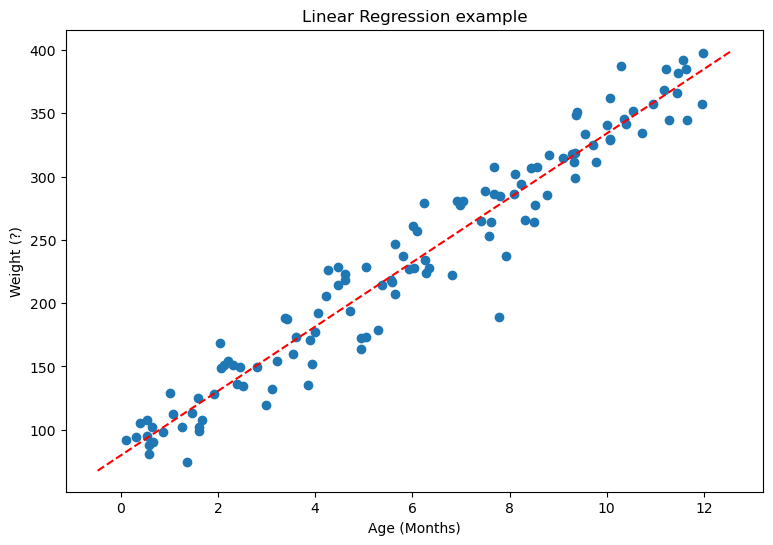

In [71]:
## here we draw a graph of the linear estimator
import matplotlib.pyplot as plt
%matplotlib inline

fig, axes = plt.subplots(1, 1, figsize=(9, 6))
axes.scatter(month_data, weight_data)

# y = mx + c 
# m = slope/gradient - calculated by OLS
# c = intercept - calculated by OLS
x_vals = np.array(axes.get_xlim()) # get x values
# y = mx + c
y_vals = (slope * x_vals) + intercept  # y = mx + c
# plot on graph useing red colour
axes.plot(x_vals, y_vals, 'r--')

# labels for the plot
plt.title('Linear Regression example')
plt.xlabel('Age (Months)')
plt.ylabel('Weight (?)')

In [72]:
x_vals = np.array(axes.get_xlim())
x_vals

array([-1.13225444, 13.22610293])

In [73]:
y_vals = params[0] + params[1] * x_vals
y_vals

array([ 50.97960004, 416.06767531])

In [74]:
print("intercept is", params[0])

intercept is 79.76928564070873


In [75]:
print("slope is", params[1])

slope is 25.426869229260962


## Very strong positive correlation between x and y!

In [76]:
np.corrcoef(month_data, weight_data)

array([[1.        , 0.97196243],
       [0.97196243, 1.        ]])